In [108]:
import numpy as np
from matplotlib import pyplot as plt
from astropy.io import fits
from photutils import aperture_photometry, CircularAnnulus, CircularAperture, find_peaks
from glob import glob
from astropy.stats import sigma_clipped_stats

%matplotlib inline

In [199]:
# Make a list of reduced images - i.e. after bias and flat field are applied (here, I have just done this on the unreduced data,
# but the code is exactly the same)

filelist = glob("O120308_01*")
print (filelist)

['O120308_0183.fits', 'O120308_0176.fits', 'O120308_0177.fits', 'O120308_0182.fits', 'O120308_0189.fits', 'O120308_0185.fits', 'O120308_0192.fits', 'O120308_0184.fits', 'O120308_0188.fits', 'O120308_0191.fits', 'O120308_0187.fits', 'O120308_0186.fits', 'O120308_0190.fits', 'O120308_0178.fits', 'O120308_0181.fits', 'O120308_0175.fits', 'O120308_0180.fits', 'O120308_0179.fits']


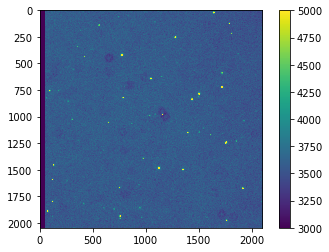

In [200]:
# First lets load one image from the list of images, and see where the region of interest is.

image = fits.open(filelist[10])

fig, ax = plt.subplots()
pixels = ax.imshow(image[0].data, vmin=3000, vmax=5000)
cbar = fig.colorbar(pixels, ax=ax)

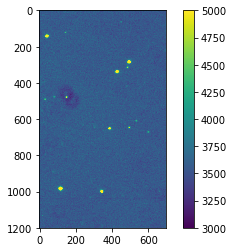

In [201]:
# Now we can take a subsection of the image

image_region = image[0].data[500:1700,1000:1700]

fig, ax = plt.subplots()
pixels = ax.imshow(image_region, vmin=3000, vmax=5000)
cbar = fig.colorbar(pixels, ax=ax)

In [202]:
# We get the mean counts, and the standard deviation
# (this is a similar function to mad_std in the example)

mean, median, std = sigma_clipped_stats(image_region, sigma=3.0)
print (mean, median, std)

3572.569816571729 3573.0 55.76084609649334


In [206]:
# Rather than DAOfind, I've used "find_peaks", which does exactly the same job
# We set a threshold, in this case it's 5x the standard deviation above the background

threshold = median + (5. * std)
sources = find_peaks(image_region, threshold, box_size=11)

In [207]:
# Now  lets look at the list of sources we get

sources

x_peak,y_peak,peak_value
int64,int64,uint16
452,65,4215
145,123,4488
43,143,26170
699,225,4004
496,286,32067
489,315,4836
429,340,26156
583,398,3988
482,418,3908


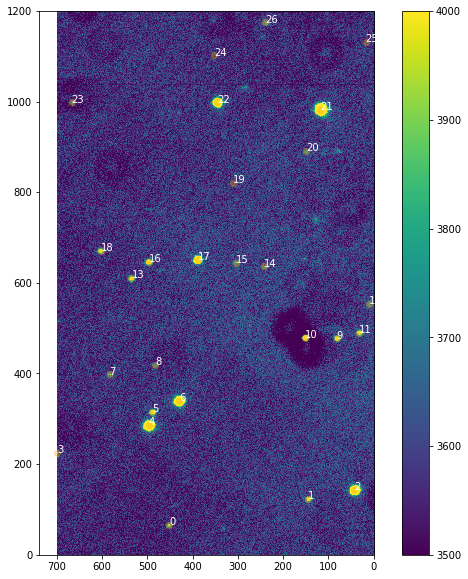

In [211]:
# We can plot these on the image region

fig, ax = plt.subplots(figsize=(10,10))
pixels = ax.imshow(image_region, vmin=3500, vmax=4000, origin="left")
ax.invert_xaxis()

ax.scatter(sources['x_peak'], sources['y_peak'], alpha=0.3, color="orange")
cbar = fig.colorbar(pixels, ax=ax)

# And annotate each source so they're easy to identify
for i in range(0, len(sources)):
    ax.annotate(i, (sources['x_peak'][i], sources['y_peak'][i]), color='white')


nnser is 16 

A is 17

B is 22

C is 21

D is 6


In [174]:
# Now lets test some photometery on these sources...

positions = np.transpose((sources['x_peak'], sources['y_peak']))
# Set up aperture and annulus
aperture = CircularAperture(positions, r=10.)
annulus_aperture = CircularAnnulus(positions, r_in=15., r_out=20.)
# Make a list of apertures
apers = [aperture, annulus_aperture]
# And run aperture photometry
phot_table = aperture_photometry(image_region, apers)
# We calculate the mean counts in each pixel in the background annulus, and the n multiply by the area
# in the aperture to get the total background counts within each aperture 
bkg_mean = phot_table['aperture_sum_1'] / annulus_aperture.area()
bkg_sum = bkg_mean * aperture.area()
# Now we get the final table of background subtracted counts within each apertu re
final_sum = phot_table['aperture_sum_0'] - bkg_sum

mags = -2.5*np.log10(final_sum)

In [212]:
mags

-11.334394019371246
-11.881337100516348
-15.447714591725346
-11.546739030130095
-15.753015405694576
-12.340727338230577
-15.515872813129759
-11.03542947741354
-10.612259969629594
-12.035721383894293
-13.22985447304884


In [214]:
# Now, we can calculate the zeropoint for each of sources A, B, C and D

ZP_A  = 15.8  - mags[17]
ZP_B  = 15.1  - mags[22] 
ZP_C  = 13.7  - mags[21] 
ZP_D  = 13.7  - mags[6]  

zeropoints = [ZP_A, ZP_B, ZP_C, ZP_D]
print (zeropoints)

[30.041769357599076, 30.094827278190103, 30.09328099756037, 29.215872813129756]


In [215]:
# Averaging them together (and sigma clipping)
mean_zpt, median_zpt, std_zpt = sigma_clipped_stats(zeropoints, sigma=2)
print (mean_zpt)

30.094054137875236


In [225]:
# Finally, we run photomety on all the images. We just use the source list from
#  above (i.e. we re-use aperture and annulus)

results = []

for file in filelist:
    image = fits.open(file)
    
    # We get the time each image was taken from the header
    time = (image[0].header['UT'])

    # Trim the image as above
    image_region = image[0].data[500:1700,1000:1700]

    # Do photometry
    phot_table = aperture_photometry(image_region, apers)
    bkg_mean = phot_table['aperture_sum_1'] / annulus_aperture.area()
    bkg_sum = bkg_mean * aperture.area()
    final_sum = phot_table['aperture_sum_0'] - bkg_sum
    mags = -2.5*np.log10(final_sum)
    
    # Now find the zeropoint for that image  
    ZP_A  = 15.8  - mags[17]
    ZP_B  = 15.1  - mags[22] 
    ZP_C  = 13.7  - mags[21] 
    ZP_D  = 13.7  - mags[6]  
    zeropoints = [ZP_A, ZP_B, ZP_C, ZP_D]
    mean_zpt, median_zpt, std_zpt = sigma_clipped_stats(zeropoints, sigma=2)

    # Finally, we apply this zeropoint to the photometry on nnSer
    nnser = mags[16]+mean_zpt
    
    # and append our results to an array and print to screen
    results.append([time, nnser])
    print (time, nnser)

/Users/mf/anaconda2/envs/astroconda3/lib/python3.6/site-packages/ipykernel_launcher.py:20: RuntimeWarning: invalid value encountered in log10
/Users/mf/anaconda2/envs/astroconda3/lib/python3.6/site-packages/ipykernel_launcher.py:20: RuntimeWarning: invalid value encountered in log10
/Users/mf/anaconda2/envs/astroconda3/lib/python3.6/site-packages/ipykernel_launcher.py:20: RuntimeWarning: invalid value encountered in log10
/Users/mf/anaconda2/envs/astroconda3/lib/python3.6/site-packages/ipykernel_launcher.py:20: RuntimeWarning: invalid value encountered in log10
/Users/mf/anaconda2/envs/astroconda3/lib/python3.6/site-packages/ipykernel_launcher.py:20: RuntimeWarning: invalid value encountered in log10
/Users/mf/anaconda2/envs/astroconda3/lib/python3.6/site-packages/ipykernel_launcher.py:20: RuntimeWarning: invalid value encountered in log10
/Users/mf/anaconda2/envs/astroconda3/lib/python3.6/site-packages/ipykernel_launcher.py:20: RuntimeWarning: invalid value encountered in log10
/Users

03:08:35.049 21.290598119762915
02:55:10.873 17.50309070186132
02:56:36.574 17.49255121392566
03:06:39.454 22.497628790413934
03:20:10.024 17.479067102074072
03:12:26.645 18.75202940839751
03:25:57.417 17.481064001421093
03:10:30.831 21.27709927288058
03:18:14.335 17.49310463590917
03:24:02.236 17.473785097357837
03:16:18.615 17.49799850088591
03:14:22.685 17.49402712380996
03:22:05.837 17.504627727047122
02:58:02.653 17.51725076333117
03:04:43.753 21.201639012360847
02:53:45.905 17.47033046951266
03:02:48.093 17.749060931251247
03:00:52.123 17.51403133177395


/Users/mf/anaconda2/envs/astroconda3/lib/python3.6/site-packages/ipykernel_launcher.py:20: RuntimeWarning: invalid value encountered in log10
/Users/mf/anaconda2/envs/astroconda3/lib/python3.6/site-packages/ipykernel_launcher.py:20: RuntimeWarning: invalid value encountered in log10
/Users/mf/anaconda2/envs/astroconda3/lib/python3.6/site-packages/ipykernel_launcher.py:20: RuntimeWarning: invalid value encountered in log10
/Users/mf/anaconda2/envs/astroconda3/lib/python3.6/site-packages/ipykernel_launcher.py:20: RuntimeWarning: invalid value encountered in log10
/Users/mf/anaconda2/envs/astroconda3/lib/python3.6/site-packages/ipykernel_launcher.py:20: RuntimeWarning: invalid value encountered in log10
/Users/mf/anaconda2/envs/astroconda3/lib/python3.6/site-packages/ipykernel_launcher.py:20: RuntimeWarning: invalid value encountered in log10
/Users/mf/anaconda2/envs/astroconda3/lib/python3.6/site-packages/ipykernel_launcher.py:20: RuntimeWarning: invalid value encountered in log10


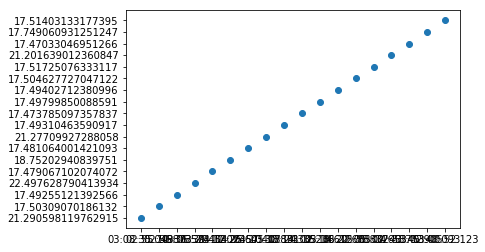